=== VISUALIZACIÓN DEL CUBO DE AGUA ===
Cargando archivo: water_cube_trajectory.pdb
Archivo cargado exitosamente: 1500 átomos encontrados
=== ANÁLISIS DE LA ESTRUCTURA DEL AGUA ===
Moléculas de agua: 500
Átomos de oxígeno: 500
Átomos de hidrógeno: 1000
Total de átomos: 1500

=== DIMENSIONES DEL CUBO ===
Dimensiones (Å): 26.14 x 26.19 x 25.93
Volumen: 17751.19 Å³ = 17.7512 nm³
Centro de masa: (12.42, 12.41, 12.46) Å

=== PROPIEDADES FÍSICAS ===
Densidad calculada: 842.61 kg/m³
Densidad del agua real: ~1000 kg/m³

Creando visualizaciones...
Creando visualización interactiva...


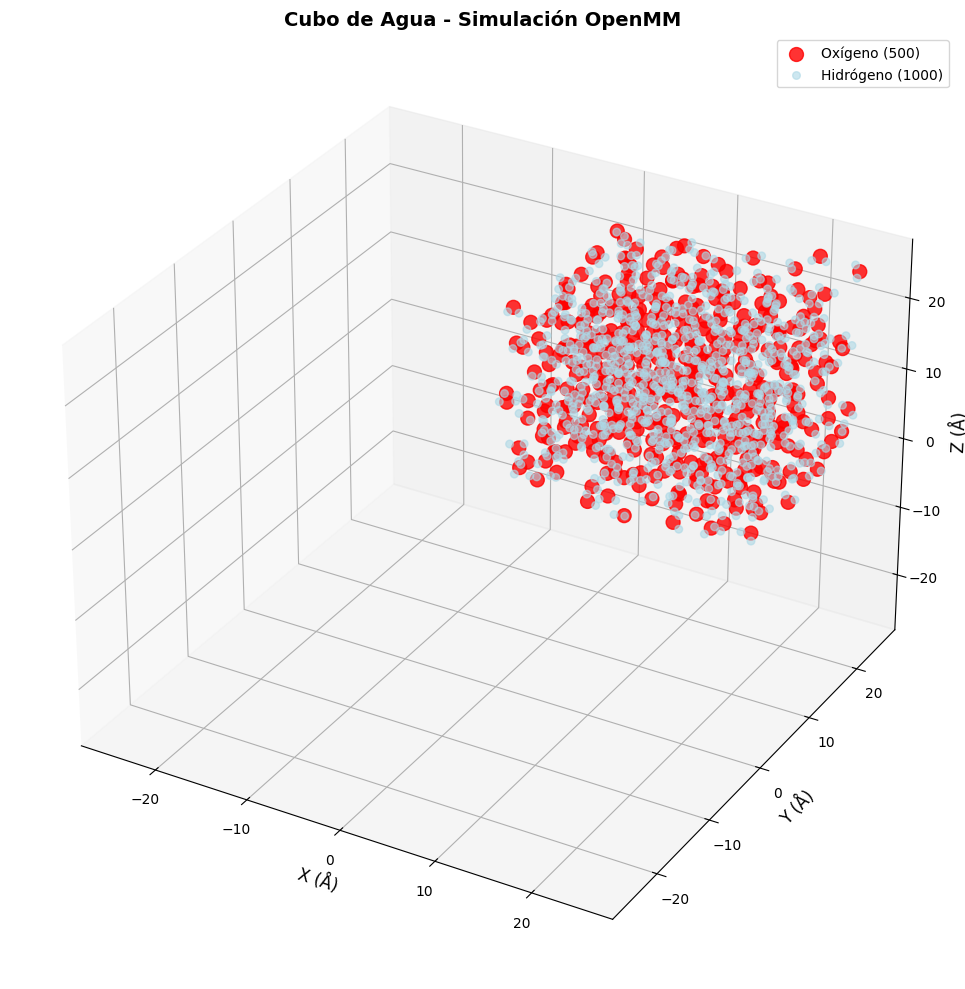

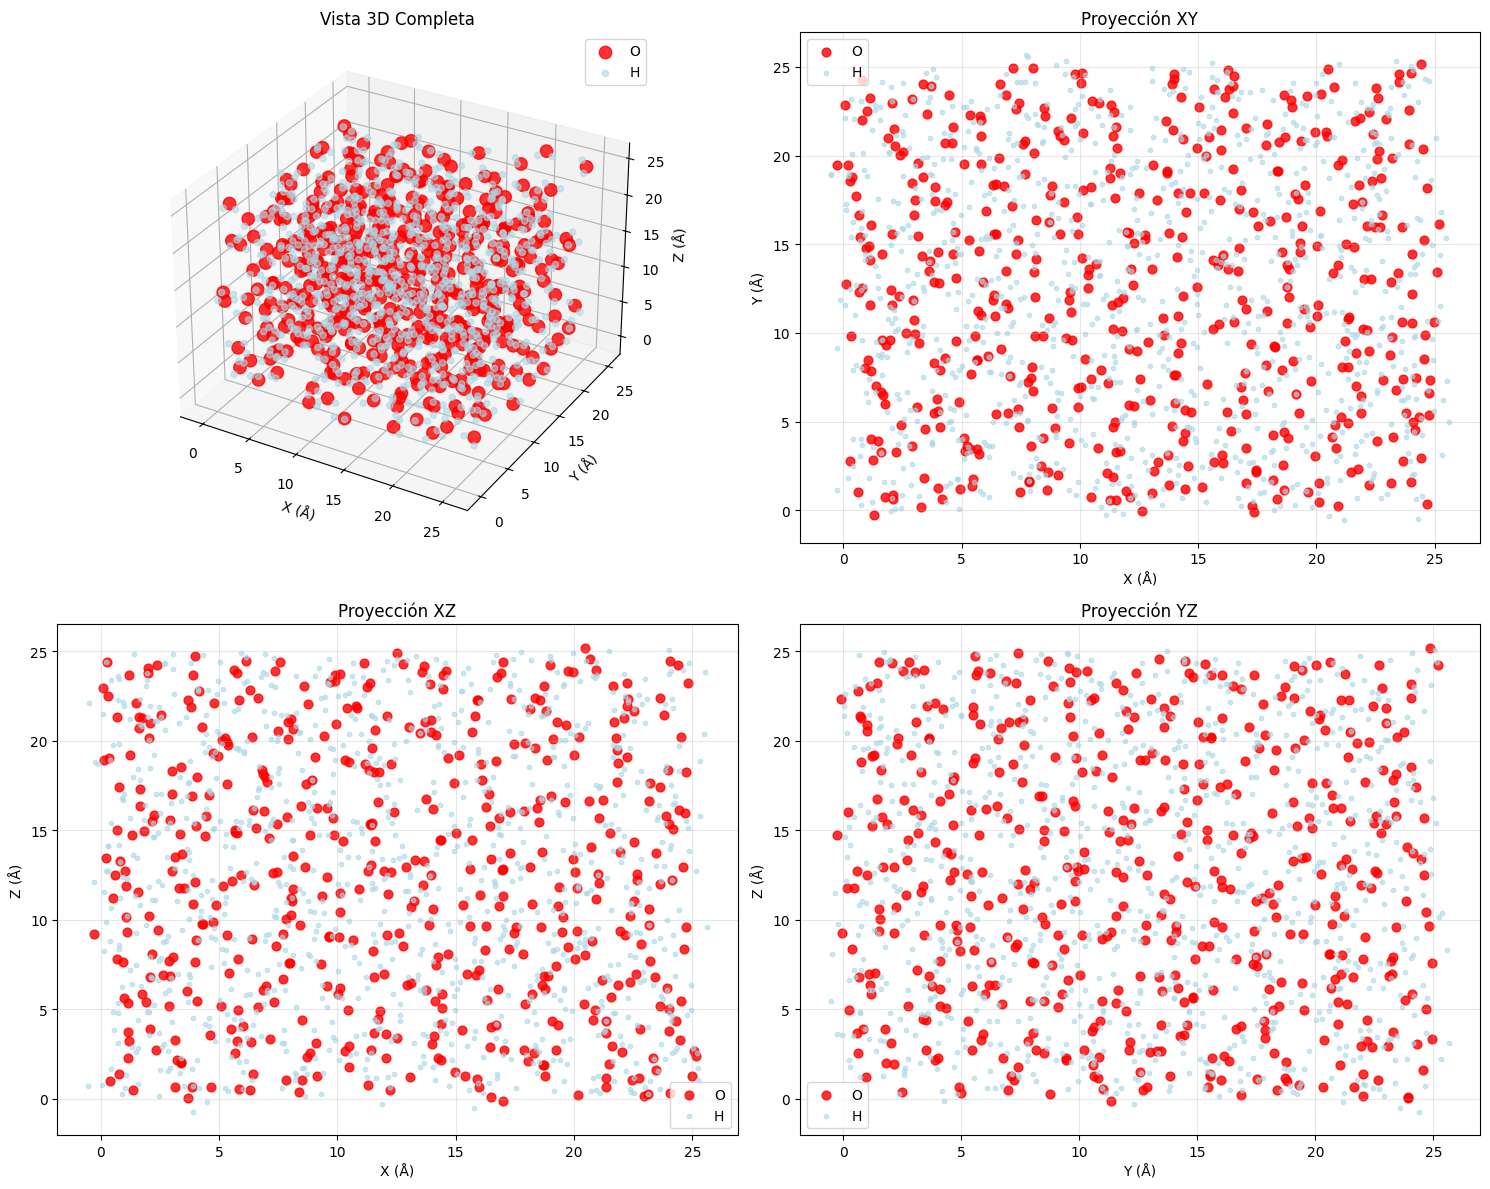

Visualización interactiva creada. Ejecuta 'viewer.show()' para mostrarla.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
import re

def parse_pdb_file(filename):
    """
    Parsea el archivo PDB y extrae las coordenadas de los átomos
    """
    atoms = []
    coordinates = []
    
    try:
        with open(filename, 'r') as file:
            for line in file:
                if line.startswith('HETATM') or line.startswith('ATOM'):
                    # Parsear línea PDB
                    atom_type = line[76:78].strip()
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    
                    atoms.append(atom_type)
                    coordinates.append([x, y, z])
                    
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo {filename}")
        return None, None
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None, None
    
    return atoms, np.array(coordinates)

def visualize_water_cube_matplotlib(atoms, coordinates, frame_title="Cubo de Agua - Simulación OpenMM"):
    """
    Visualiza el cubo de agua usando matplotlib
    """
    if atoms is None or coordinates is None:
        return None
    
    # Configuración de colores
    color_map = {
        'O': 'red',
        'H': 'lightblue',
        'HOH': 'red'  # Por si el tipo viene como HOH
    }
    
    # Configuración de tamaños
    size_map = {
        'O': 100,
        'H': 30,
        'HOH': 100
    }
    
    # Crear figura 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Separar átomos por tipo
    oxygen_coords = []
    hydrogen_coords = []
    
    for i, atom in enumerate(atoms):
        coord = coordinates[i]
        if atom in ['O', 'HOH']:
            oxygen_coords.append(coord)
        elif atom == 'H':
            hydrogen_coords.append(coord)
    
    oxygen_coords = np.array(oxygen_coords) if oxygen_coords else np.array([]).reshape(0, 3)
    hydrogen_coords = np.array(hydrogen_coords) if hydrogen_coords else np.array([]).reshape(0, 3)
    
    # Plotear oxígenos
    if len(oxygen_coords) > 0:
        ax.scatter(oxygen_coords[:, 0], oxygen_coords[:, 1], oxygen_coords[:, 2],
                  c='red', s=100, alpha=0.8, label=f'Oxígeno ({len(oxygen_coords)})')
    
    # Plotear hidrógenos
    if len(hydrogen_coords) > 0:
        ax.scatter(hydrogen_coords[:, 0], hydrogen_coords[:, 1], hydrogen_coords[:, 2],
                  c='lightblue', s=30, alpha=0.6, label=f'Hidrógeno ({len(hydrogen_coords)})')
    
    # Configurar ejes y título
    ax.set_xlabel('X (Å)', fontsize=12)
    ax.set_ylabel('Y (Å)', fontsize=12)
    ax.set_zlabel('Z (Å)', fontsize=12)
    ax.set_title(frame_title, fontsize=14, fontweight='bold')
    
    # Leyenda
    ax.legend()
    
    # Configurar límites iguales para todos los ejes
    all_coords = coordinates
    if len(all_coords) > 0:
        max_range = np.max(np.abs(all_coords)) * 1.1
        ax.set_xlim(-max_range, max_range)
        ax.set_ylim(-max_range, max_range)
        ax.set_zlim(-max_range, max_range)
    
    # Grid
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

def visualize_water_cube_py3dmol(filename):
    """
    Visualiza el cubo de agua usando py3Dmol directamente desde el archivo PDB
    """
    try:
        # Leer el archivo PDB
        with open(filename, 'r') as file:
            pdb_content = file.read()
        
        # Crear visualizador
        viewer = py3Dmol.view(width=800, height=600)
        
        # Agregar el modelo PDB
        viewer.addModel(pdb_content, 'pdb')
        
        # Configurar estilos
        viewer.setStyle({'elem': 'O'}, {'sphere': {'color': 'red', 'radius': 0.8}})
        viewer.setStyle({'elem': 'H'}, {'sphere': {'color': 'white', 'radius': 0.4}})
        
        # Agregar enlaces de agua
        viewer.addStyle({}, {'stick': {'radius': 0.1}})
        
        # Configurar visualización
        viewer.setBackgroundColor('white')
        viewer.zoomTo()
        
        return viewer
        
    except Exception as e:
        print(f"Error en py3Dmol: {e}")
        return None

def analyze_water_structure(atoms, coordinates):
    """
    Analiza la estructura del agua y proporciona estadísticas
    """
    if atoms is None or coordinates is None:
        return
    
    # Contar átomos
    oxygen_count = sum(1 for atom in atoms if atom in ['O', 'HOH'])
    hydrogen_count = sum(1 for atom in atoms if atom == 'H')
    water_molecules = oxygen_count  # Cada oxígeno representa una molécula
    
    # Calcular dimensiones del cubo
    if len(coordinates) > 0:
        min_coords = np.min(coordinates, axis=0)
        max_coords = np.max(coordinates, axis=0)
        dimensions = max_coords - min_coords
        
        # Calcular centro de masa
        center_of_mass = np.mean(coordinates, axis=0)
        
        # Calcular densidad aproximada
        volume_angstrom3 = np.prod(dimensions)
        volume_nm3 = volume_angstrom3 * 1e-3  # Conversión Å³ a nm³
        
        # Masa de agua: 18.015 u, cada u = 1.66054e-27 kg
        mass_per_molecule_kg = 18.015 * 1.66054e-27
        total_mass_kg = water_molecules * mass_per_molecule_kg
        
        # Densidad en kg/m³
        volume_m3 = volume_nm3 * 1e-27
        density_kg_m3 = total_mass_kg / volume_m3 if volume_m3 > 0 else 0
        
        print("=== ANÁLISIS DE LA ESTRUCTURA DEL AGUA ===")
        print(f"Moléculas de agua: {water_molecules}")
        print(f"Átomos de oxígeno: {oxygen_count}")
        print(f"Átomos de hidrógeno: {hydrogen_count}")
        print(f"Total de átomos: {len(atoms)}")
        print()
        print("=== DIMENSIONES DEL CUBO ===")
        print(f"Dimensiones (Å): {dimensions[0]:.2f} x {dimensions[1]:.2f} x {dimensions[2]:.2f}")
        print(f"Volumen: {volume_angstrom3:.2f} Å³ = {volume_nm3:.4f} nm³")
        print(f"Centro de masa: ({center_of_mass[0]:.2f}, {center_of_mass[1]:.2f}, {center_of_mass[2]:.2f}) Å")
        print()
        print("=== PROPIEDADES FÍSICAS ===")
        print(f"Densidad calculada: {density_kg_m3:.2f} kg/m³")
        print(f"Densidad del agua real: ~1000 kg/m³")
        print("=" * 50)

def create_multiple_views(atoms, coordinates):
    """
    Crea múltiples vistas del cubo de agua
    """
    if atoms is None or coordinates is None:
        return
    
    # Crear figura con subplots
    fig = plt.figure(figsize=(15, 12))
    
    # Vista 3D principal
    ax1 = fig.add_subplot(221, projection='3d')
    
    # Separar átomos
    oxygen_coords = np.array([coordinates[i] for i, atom in enumerate(atoms) if atom in ['O', 'HOH']])
    hydrogen_coords = np.array([coordinates[i] for i, atom in enumerate(atoms) if atom == 'H'])
    
    if len(oxygen_coords) > 0:
        ax1.scatter(oxygen_coords[:, 0], oxygen_coords[:, 1], oxygen_coords[:, 2],
                   c='red', s=80, alpha=0.8, label='O')
    if len(hydrogen_coords) > 0:
        ax1.scatter(hydrogen_coords[:, 0], hydrogen_coords[:, 1], hydrogen_coords[:, 2],
                   c='lightblue', s=20, alpha=0.6, label='H')
    
    ax1.set_title('Vista 3D Completa')
    ax1.set_xlabel('X (Å)')
    ax1.set_ylabel('Y (Å)')
    ax1.set_zlabel('Z (Å)')
    ax1.legend()
    
    # Proyección XY
    ax2 = fig.add_subplot(222)
    if len(oxygen_coords) > 0:
        ax2.scatter(oxygen_coords[:, 0], oxygen_coords[:, 1], c='red', s=40, alpha=0.8, label='O')
    if len(hydrogen_coords) > 0:
        ax2.scatter(hydrogen_coords[:, 0], hydrogen_coords[:, 1], c='lightblue', s=10, alpha=0.6, label='H')
    ax2.set_title('Proyección XY')
    ax2.set_xlabel('X (Å)')
    ax2.set_ylabel('Y (Å)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Proyección XZ
    ax3 = fig.add_subplot(223)
    if len(oxygen_coords) > 0:
        ax3.scatter(oxygen_coords[:, 0], oxygen_coords[:, 2], c='red', s=40, alpha=0.8, label='O')
    if len(hydrogen_coords) > 0:
        ax3.scatter(hydrogen_coords[:, 0], hydrogen_coords[:, 2], c='lightblue', s=10, alpha=0.6, label='H')
    ax3.set_title('Proyección XZ')
    ax3.set_xlabel('X (Å)')
    ax3.set_ylabel('Z (Å)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Proyección YZ
    ax4 = fig.add_subplot(224)
    if len(oxygen_coords) > 0:
        ax4.scatter(oxygen_coords[:, 1], oxygen_coords[:, 2], c='red', s=40, alpha=0.8, label='O')
    if len(hydrogen_coords) > 0:
        ax4.scatter(hydrogen_coords[:, 1], hydrogen_coords[:, 2], c='lightblue', s=10, alpha=0.6, label='H')
    ax4.set_title('Proyección YZ')
    ax4.set_xlabel('Y (Å)')
    ax4.set_ylabel('Z (Å)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

def main_visualization(pdb_filename="water_cube_trajectory.pdb"):
    """
    Función principal para visualizar el cubo de agua
    """
    print("=== VISUALIZACIÓN DEL CUBO DE AGUA ===")
    print(f"Cargando archivo: {pdb_filename}")
    
    # Parsear archivo PDB
    atoms, coordinates = parse_pdb_file(pdb_filename)
    
    if atoms is None:
        print("No se pudo cargar el archivo. Asegúrate de que existe y está en el directorio correcto.")
        return None
    
    print(f"Archivo cargado exitosamente: {len(atoms)} átomos encontrados")
    
    # Análisis de la estructura
    analyze_water_structure(atoms, coordinates)
    
    # Crear visualizaciones
    print("\nCreando visualizaciones...")
    
    # 1. Visualización 3D principal con matplotlib
    fig1, ax1 = visualize_water_cube_matplotlib(atoms, coordinates)
    
    # 2. Múltiples vistas
    fig2 = create_multiple_views(atoms, coordinates)
    
    # 3. Visualización interactiva con py3Dmol
    print("Creando visualización interactiva...")
    viewer = visualize_water_cube_py3dmol(pdb_filename)
    
    # Mostrar gráficos
    plt.show()
    
    if viewer:
        print("Visualización interactiva creada. Ejecuta 'viewer.show()' para mostrarla.")
        return fig1, fig2, viewer
    else:
        return fig1, fig2, None

# Función para usar con archivos específicos
def visualize_custom_pdb(filename):
    """
    Visualiza un archivo PDB específico
    """
    return main_visualization(filename)

# Ejecutar visualización
if __name__ == "__main__":
    # Visualizar el archivo generado por OpenMM
    figures_and_viewer = main_visualization("water_cube_trajectory.pdb")
    
    # Si quieres visualizar un archivo específico:
    # figures_and_viewer = visualize_custom_pdb("tu_archivo.pdb")